# Pilot ETF Data and Exploratory Analysis

**Status: TEMPORARY / PILOT.** SPY / IEF / GLD, equal-weight, 2010-01-04 to 2025-12-31.

This notebook loads the already-downloaded, already-validated pilot dataset and reuses functions from `src/` to reproduce the pilot EDA. It does not re-download data (the raw snapshot in `data/raw/` is treated as immutable) and does not fit any GARCH, Markov-switching, HMM, VaR/ES, or other advanced model.

See `notes/pilot_eda.md` for the full written discussion of these results.

## 1. Objective

Build a transparent, reproducible pilot pipeline: validated adjusted prices → simple/log returns → equal-weight portfolio return → summary statistics → 21-day rolling volatility → return and squared-return ACF. This is descriptive exploratory work only, ahead of any conditional-variance or regime modelling.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

from src.returns import (
    calculate_equal_weight_portfolio_returns,
    calculate_log_returns,
    calculate_simple_returns,
    rolling_volatility,
)

TICKERS = ["SPY", "IEF", "GLD"]
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
%matplotlib inline

## 2. Load validated data

Loads the adjusted-price panel produced by `scripts/02_validate_and_build_processed_data.py` from the immutable raw snapshot. Raw-data validation (missingness, duplicate dates, sorting, non-positive prices) was already performed by that script; see `data/metadata/pilot_etf_yahoo_2010_2025_validation_report.json`.

In [2]:
adj_prices = pd.read_csv(PROCESSED_DIR / "pilot_adjusted_prices.csv", index_col="Date", parse_dates=True)
print(adj_prices.shape)
print("Range:", adj_prices.index.min().date(), "to", adj_prices.index.max().date())
print("Missing values per ticker:")
print(adj_prices.isna().sum())

(4024, 3)
Range: 2010-01-04 to 2025-12-31
Missing values per ticker:
SPY    0
IEF    0
GLD    0
dtype: int64


## 3. Inspect adjusted prices

In [3]:
adj_prices.head()

,SPY,IEF,GLD
Date,,,
2010-01-04,84.578445,60.713688,109.800003
2010-01-05,84.802383,60.980270,109.699997
2010-01-06,84.862068,60.734196,111.510002
2010-01-07,85.220322,60.734196,110.820000
2010-01-08,85.503906,60.809402,111.370003


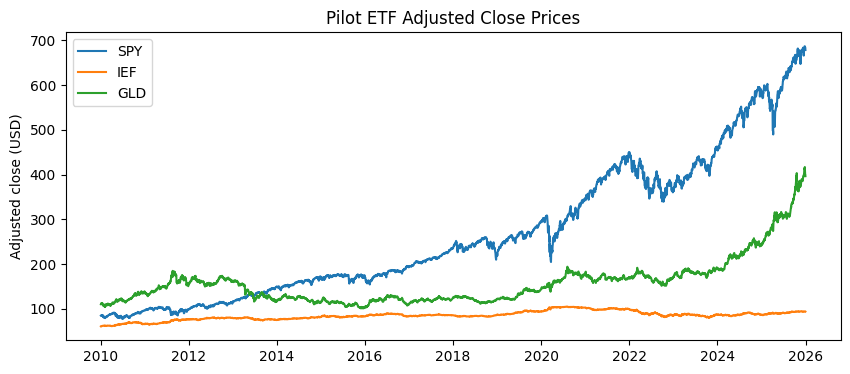

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
for ticker in TICKERS:
    ax.plot(adj_prices.index, adj_prices[ticker], label=ticker)
ax.set_title("Pilot ETF Adjusted Close Prices")
ax.set_ylabel("Adjusted close (USD)")
ax.legend()
plt.show()

## 4. Calculate simple and log returns

Both are calculated for learning/validation; the equal-weight portfolio below uses **simple** returns. See `tests/test_returns.py` for manual hand-computed validation of both.

In [5]:
simple_returns = calculate_simple_returns(adj_prices)
log_returns = calculate_log_returns(adj_prices)
simple_returns.head()

,SPY,IEF,GLD
Date,,,
2010-01-04,NaN,NaN,NaN
2010-01-05,0.002648,0.004391,-0.000911
2010-01-06,0.000704,-0.004035,0.016500
2010-01-07,0.004222,0.000000,-0.006188
2010-01-08,0.003328,0.001238,0.004963


## 5. Construct equal-weight portfolio

TEMPORARY / PILOT construction: fixed weights [1/3, 1/3, 1/3], no rebalancing, built directly from asset **simple** returns (not from averaging log returns).

In [6]:
portfolio_returns = calculate_equal_weight_portfolio_returns(simple_returns, assets=TICKERS)
portfolio_returns.name = "portfolio_return"
portfolio_returns.head()

Date
2010-01-04         NaN
2010-01-05    0.002043
2010-01-06    0.004389
2010-01-07   -0.000655
2010-01-08    0.003176
Name: portfolio_return, dtype: float64

## 6. Summary statistics

In [7]:
combined = simple_returns[TICKERS].copy()
combined["Equal-weight portfolio"] = portfolio_returns

TRADING_DAYS_PER_YEAR = 252

def summarize(s):
    c = s.dropna()
    return {
        "count": int(c.shape[0]), "mean": c.mean(), "std": c.std(),
        "min": c.min(), "p25": c.quantile(0.25), "median": c.median(),
        "p75": c.quantile(0.75), "max": c.max(),
        "skewness": stats.skew(c), "excess_kurtosis": stats.kurtosis(c, fisher=True),
        "annualised_mean": c.mean() * TRADING_DAYS_PER_YEAR,
        "annualised_volatility": c.std() * (TRADING_DAYS_PER_YEAR ** 0.5),
    }

summary = pd.DataFrame({name: summarize(combined[name]) for name in combined.columns}).T
summary

,count,mean,std,min,p25,median,p75,max,skewness,excess_kurtosis,annualised_mean,annualised_volatility
SPY,4023.0,0.000577,0.010841,-0.109424,-0.003706,0.000705,0.005790,0.105019,-0.334441,12.100869,0.145291,0.172097
IEF,4023.0,0.000116,0.004178,-0.025072,-0.002411,0.000244,0.002599,0.026416,0.050603,2.318153,0.029348,0.066317
GLD,4023.0,0.000369,0.009964,-0.087808,-0.004785,0.000522,0.005618,0.049038,-0.420933,4.360090,0.092953,0.158168
Equal-weight portfolio,4023.0,0.000354,0.005219,-0.045019,-0.002296,0.000540,0.003043,0.046283,-0.162254,7.524446,0.089198,0.082852


## 7. Correlations

In [8]:
corr = simple_returns[TICKERS].dropna().corr(method="pearson")
corr

,SPY,IEF,GLD
SPY,1.000000,-0.264865,0.052359
IEF,-0.264865,1.000000,0.283277
GLD,0.052359,0.283277,1.000000


## 8. Return plots

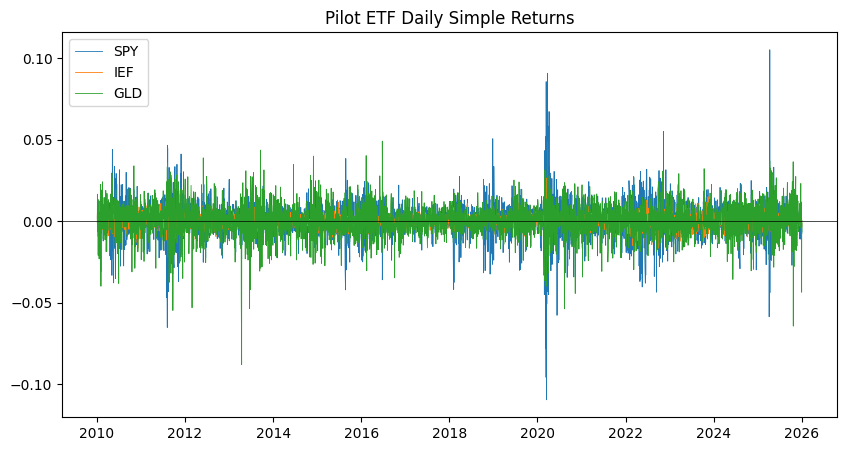

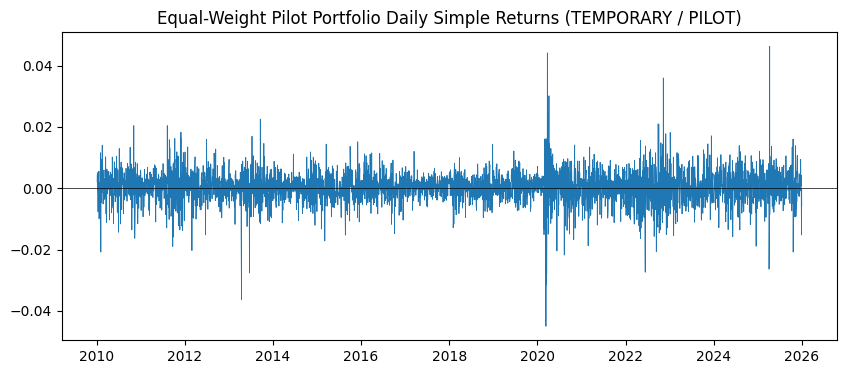

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
for ticker in TICKERS:
    ax.plot(combined.index, combined[ticker], label=ticker, linewidth=0.6)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Pilot ETF Daily Simple Returns")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(portfolio_returns.index, portfolio_returns, linewidth=0.6)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Equal-Weight Pilot Portfolio Daily Simple Returns (TEMPORARY / PILOT)")
plt.show()

## 9. 21-day rolling volatility

Trailing (not centred) 21-trading-day rolling standard deviation — a backward-looking descriptive statistic, not a forecast.

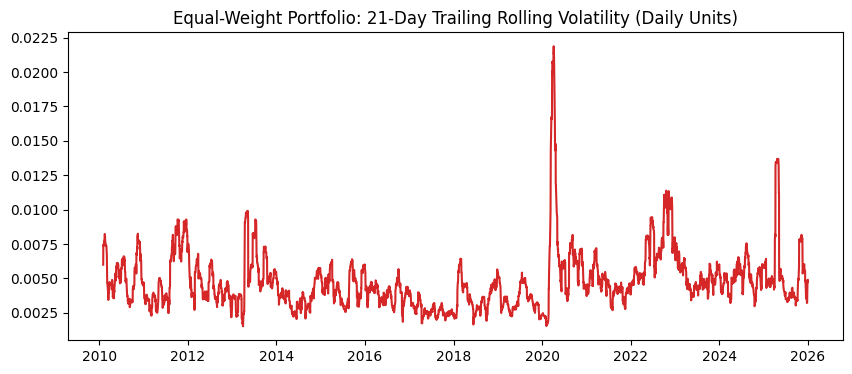

In [10]:
roll_vol = rolling_volatility(portfolio_returns, window=21)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(roll_vol.index, roll_vol, color="tab:red")
ax.set_title("Equal-Weight Portfolio: 21-Day Trailing Rolling Volatility (Daily Units)")
plt.show()

## 10. Return ACF

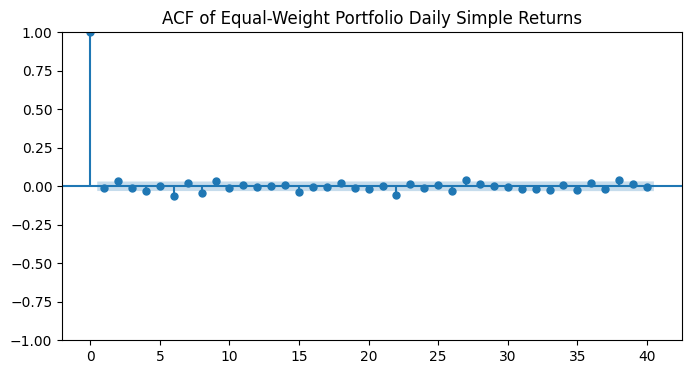

In [11]:
portfolio_clean = portfolio_returns.dropna()
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(portfolio_clean, lags=40, ax=ax, title="ACF of Equal-Weight Portfolio Daily Simple Returns")
plt.show()

## 11. Squared-return ACF

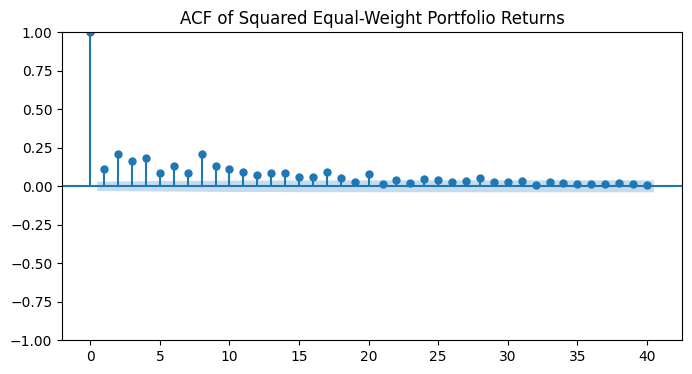

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(portfolio_clean ** 2, lags=40, ax=ax, title="ACF of Squared Equal-Weight Portfolio Returns")
plt.show()

## 12. Preliminary interpretation

The return ACF is small in magnitude at most lags (mostly inside or only marginally outside the approximate 95% band of ±~0.031), while the squared-return ACF is visibly larger and decays slowly across the first ~30 lags. This pattern is consistent with volatility clustering: the direction of returns shows weak linear persistence, while the magnitude of returns appears more persistent. The 21-day rolling volatility plot above shows the same qualitative pattern directly — volatility is not constant through time and tends to cluster (e.g. around early 2020).

These are descriptive, visual observations from a single pilot sample — no formal statistical test (e.g. Ljung-Box) was run, and no causal or forecasting claim is made.

## 13. Limitations

- Yahoo Finance / `yfinance` is a convenient public pilot source, not an official or institutional data vendor; not yet cross-validated against a second source.
- Single pilot universe (SPY/IEF/GLD) and single fixed equal-weight construction — not the final thesis specification.
- High excess kurtosis (SPY: 12.1, portfolio: 7.5) indicates heavy tails not captured by mean/std alone.
- No formal dependence or autocorrelation significance testing performed.

## 14. Next step

Understand conditional variance and EWMA before implementing GARCH. No GARCH, Markov-switching, HMM, VaR/ES, or other advanced model was fitted in this notebook.